# Student Performance Predictor
## Dataset Loading

In [1]:
import pandas as pd

df = pd.read_csv("../data/Student_Performance.csv")

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [2]:
df.shape

(10000, 6)

In [3]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(127)

In [7]:
df.drop_duplicates(inplace=True)

## Categorical Feature Analysis

In [8]:
df["Extracurricular Activities"].value_counts()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64

In [9]:
df["Extracurricular Activities"].unique()

array(['Yes', 'No'], dtype=object)

In [10]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({
    "Yes": 1,
    "No": 0
})
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


## Correlation Analysis

In [11]:
df.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.004899,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.009534,0.007975,0.008719,0.915135
Extracurricular Activities,0.004899,0.009534,1.000000,-0.024008,0.013839,0.026075
Sleep Hours,0.002131,0.007975,-0.024008,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.013839,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.026075,0.050352,0.043436,1.000000


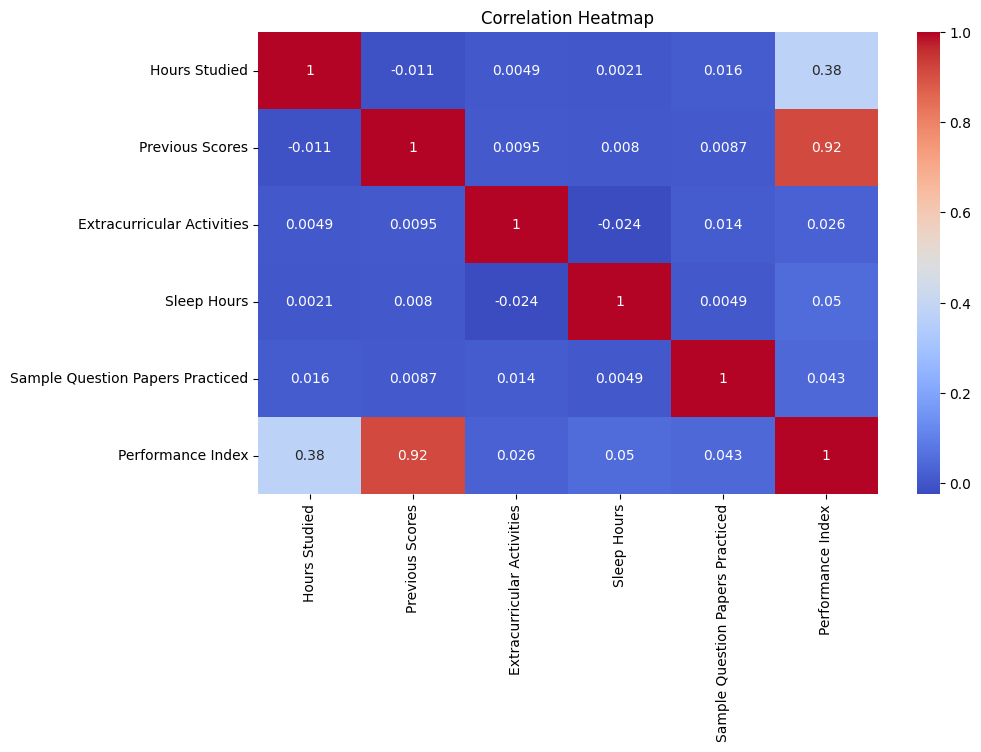

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Distribution Analysis
Understanding the distribution of numerical features helps identify patterns, skewness, and potential outliers in the dataset.

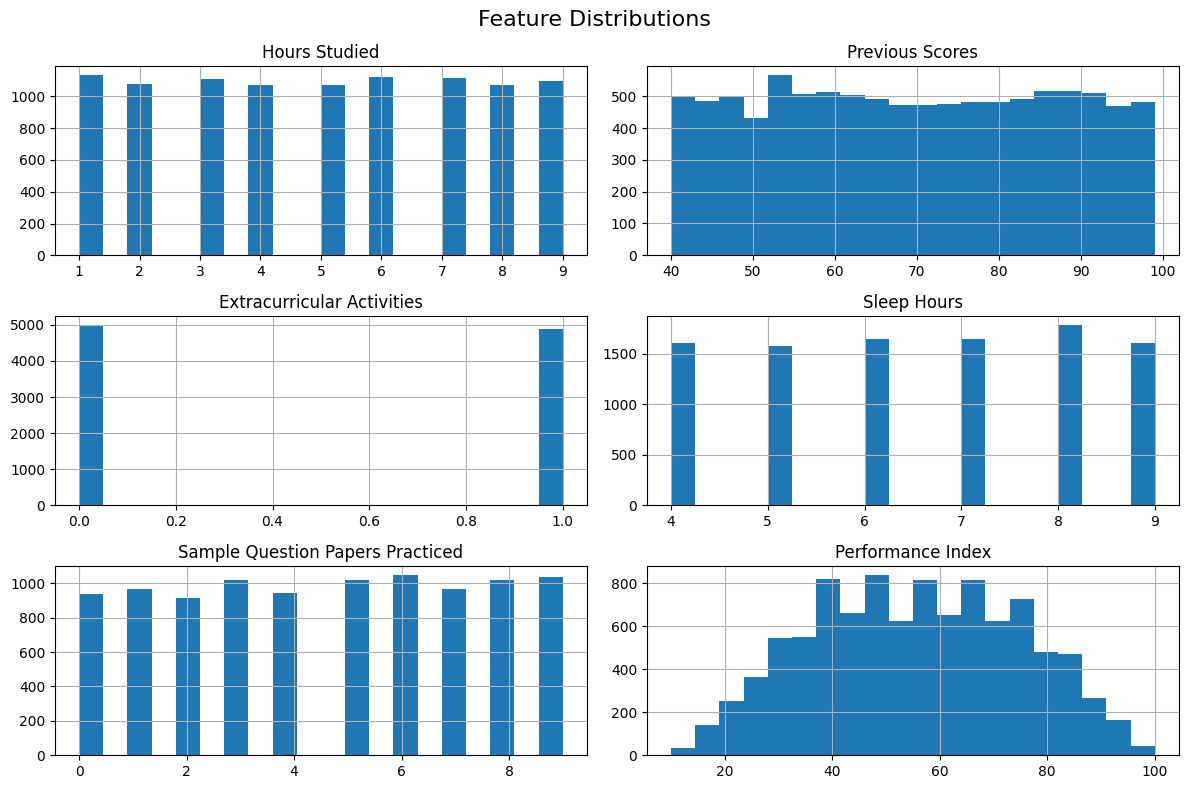

In [13]:
import matplotlib.pyplot as plt

df.hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle(
    "Feature Distributions",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "../images/feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Most numerical features appear reasonably distributed.
- The dataset does not show extreme outliers.
- Feature distributions indicate suitability for machine learning models.

# Target Variable Distribution

Analyzing the distribution of the target variable (Performance Index).

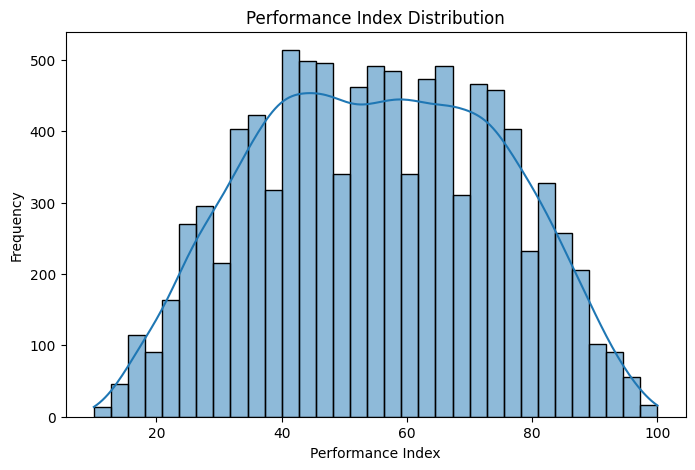

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Performance Index"],
    kde=True
)

plt.title("Performance Index Distribution")
plt.xlabel("Performance Index")
plt.ylabel("Frequency")

plt.savefig(
    "../images/performance_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The Performance Index appears normally distributed.
- No major skewness is observed.
- The target variable is suitable for regression modeling.

# Relationship Between Features and Target

Scatter plots help visualize how individual features influence student performance.

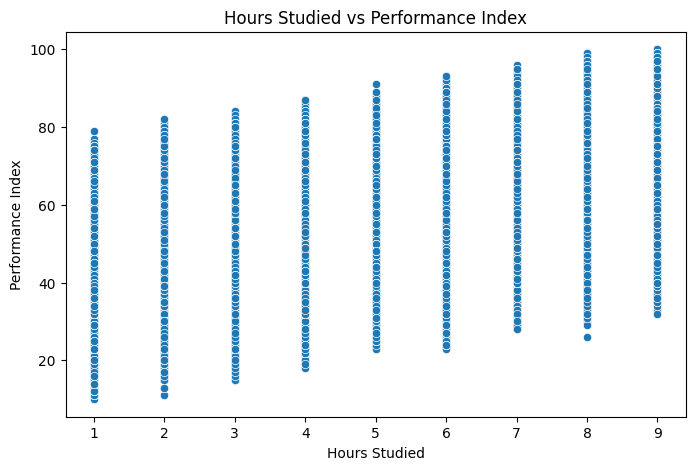

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Hours Studied",
    y="Performance Index"
)

plt.title("Hours Studied vs Performance Index")

plt.savefig(
    "../images/hours_vs_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Students who study more hours tend to achieve higher performance scores.
- A positive relationship is visible between study hours and performance.

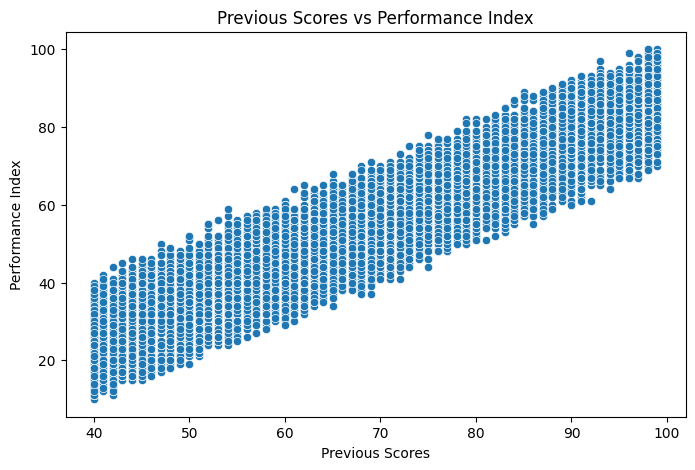

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Previous Scores",
    y="Performance Index"
)

plt.title("Previous Scores vs Performance Index")

plt.savefig(
    "../images/previous_scores_vs_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Previous Scores show a strong positive correlation with Performance Index.
- Students with better past performance generally continue to perform well.

# Key Insights from EDA

1. No missing values were found in the dataset.
2. The dataset is clean and ready for machine learning.
3. Previous Scores have the strongest influence on Performance Index.
4. Hours Studied positively impacts student performance.
5. The target variable is approximately normally distributed.
6. Relationships between features and target indicate suitability for regression models.